# Solution: Testes de Raiz Unitaria - ADF e Phillips-Perron

Este notebook contem as resolucoes completas de todos os exercicios e testes ADF/PP.

**Conteudo:**
1. Setup e geracao de dados
2. Testes ADF completos em todas as series
3. Testes PP completos em todas as series
4. Comparacao de especificacoes (n, c, ct)
5. Selecao automatica de lags (AIC, BIC, t-sig)
6. Aplicacao ao PIB EUA
7. **Exercicio 1 resolvido**: PIB do Brasil
8. **Exercicio 2 resolvido**: Sensibilidade a especificacao de lags
9. Testes em series I(2)
10. Trend-stationary vs Difference-stationary
11. Tabela resumo consolidada com decisoes
12. Exportacao de resultados em JSON

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

from chronobox.tests_stat import adf_test, pp_test

import sys
sys.path.insert(0, '..')
from utils.data_generators import (
    generate_unit_root_process,
    generate_trend_stationary,
)
from utils.plot_helpers import plot_unit_root_series

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# Diretorio de outputs
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Dicionario para acumular todos os resultados
all_results = {}

## 1. Geracao de Series Sinteticas

Geramos series com propriedades conhecidas para validar o comportamento dos testes.

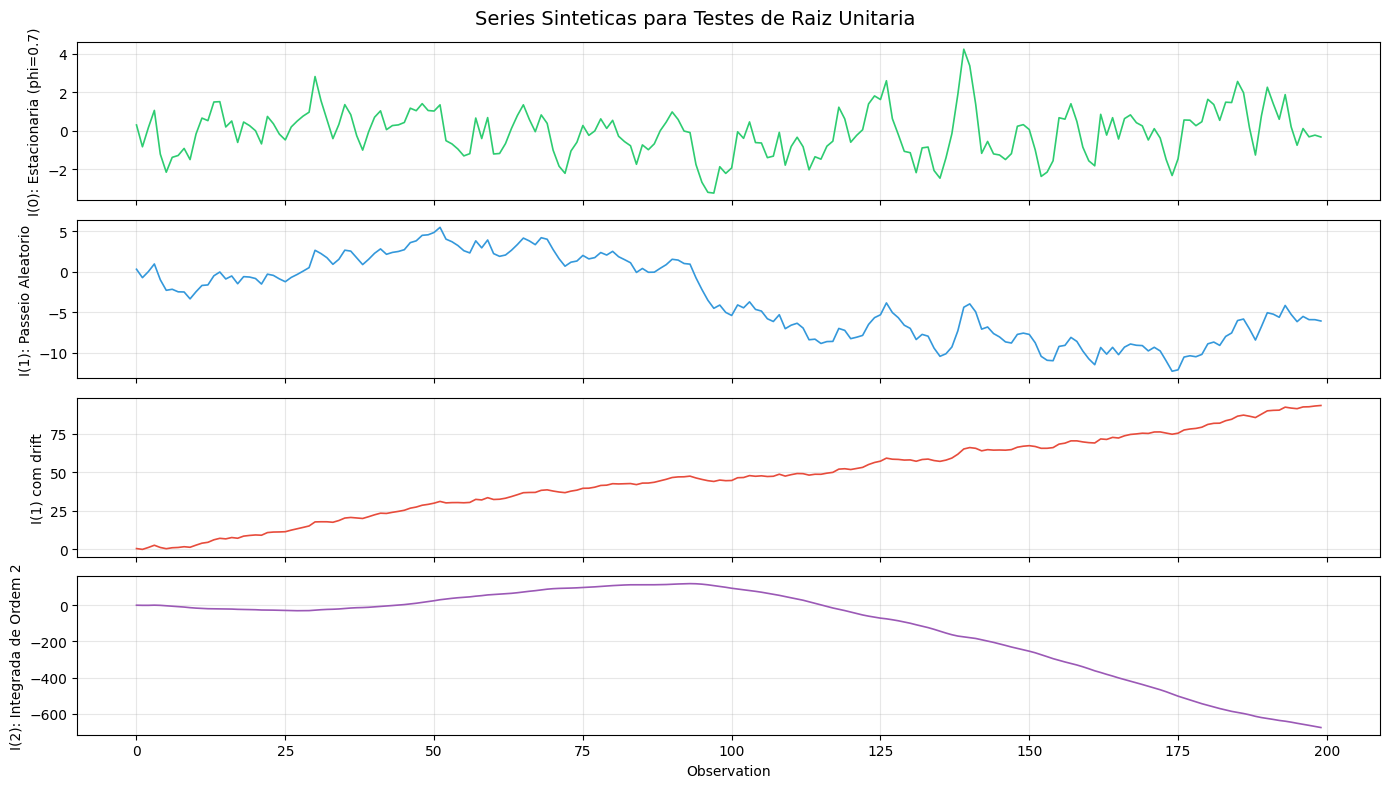

Series geradas: I(0) n=200, I(1) n=200, I(1)+drift n=200, I(2) n=200


In [2]:
# Gerar series sinteticas com seed fixa
y_stationary = generate_unit_root_process(n=200, phi=0.7, seed=42, sigma=1.0)
y_unit_root = generate_unit_root_process(n=200, phi=1.0, seed=42, sigma=1.0)
y_i2 = generate_unit_root_process(n=200, phi=1.0, seed=42, order=2, sigma=1.0)
y_rw_drift = generate_unit_root_process(n=200, phi=1.0, seed=42, drift=0.5, sigma=1.0)
df_trend = generate_trend_stationary(n=200, trend_coef=0.05, seed=42)

# Visualizar
fig = plot_unit_root_series(
    {"I(0): Estacionaria (phi=0.7)": y_stationary,
     "I(1): Passeio Aleatorio": y_unit_root,
     "I(1) com drift": y_rw_drift,
     "I(2): Integrada de Ordem 2": y_i2},
    title="Series Sinteticas para Testes de Raiz Unitaria"
)
plt.show()

print(f"Series geradas: I(0) n={len(y_stationary)}, I(1) n={len(y_unit_root)}, "
      f"I(1)+drift n={len(y_rw_drift)}, I(2) n={len(y_i2)}")

## 2. Testes ADF Completos em Todas as Series

In [3]:
def run_adf_complete(y, name, regression='c', autolag='AIC'):
    """Roda ADF e retorna dicionario de resultados."""
    r = adf_test(y, regression=regression, autolag=autolag)
    print(f"=== ADF: {name} (regression='{regression}', autolag='{autolag}') ===")
    print(r.summary())
    decision = 'Rejeita H0 (estacionaria)' if r.reject_at_5pct else 'Nao rejeita H0 (raiz unitaria)'
    print(f"Decisao a 5%: {decision}\n")
    return {
        'test': 'ADF',
        'series': name,
        'regression': regression,
        'autolag': autolag,
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'critical_values': {k: float(v) for k, v in r.critical_values.items()},
        'lags_used': int(r.lags_used) if r.lags_used is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }

In [4]:
# ADF em nivel para todas as series sinteticas
adf_results = []

# I(0) - esperamos rejeitar H0
adf_results.append(run_adf_complete(y_stationary.values, 'I(0) sintetica', 'c'))

# I(1) em nivel - esperamos NAO rejeitar
adf_results.append(run_adf_complete(y_unit_root.values, 'I(1) sintetica - nivel', 'c'))

# I(1) em primeira diferenca - esperamos rejeitar
dy = np.diff(y_unit_root.values)
adf_results.append(run_adf_complete(dy, 'I(1) sintetica - 1a diferenca', 'c'))

# I(1) com drift
adf_results.append(run_adf_complete(y_rw_drift.values, 'I(1) com drift - nivel', 'ct'))
dy_drift = np.diff(y_rw_drift.values)
adf_results.append(run_adf_complete(dy_drift, 'I(1) com drift - 1a diferenca', 'c'))

# I(2) em nivel
adf_results.append(run_adf_complete(y_i2.values, 'I(2) sintetica - nivel', 'c'))

# I(2) em primeira diferenca - esperamos NAO rejeitar (ainda I(1))
dy_i2 = np.diff(y_i2.values)
adf_results.append(run_adf_complete(dy_i2, 'I(2) sintetica - 1a diferenca', 'c'))

# I(2) em segunda diferenca - esperamos rejeitar
ddy_i2 = np.diff(y_i2.values, n=2)
adf_results.append(run_adf_complete(ddy_i2, 'I(2) sintetica - 2a diferenca', 'c'))

=== ADF: I(0) sintetica (regression='c', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : -6.664869
  p-value        : 0.005000
  Lags used      : 2

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -3.4648
      10% : -2.5745
       5% : -2.8762

  Decision (5%)  : Reject H0

  Additional Info:
    regression: c
    nobs: 197
    gamma: -0.408943
Decisao a 5%: Rejeita H0 (estacionaria)

=== ADF: I(1) sintetica - nivel (regression='c', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : -1.302095
  p-value        : 0.544820
  Lags used      : 3

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -3.4650
      10% : -2.5746
       5% : -2.8763

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nobs: 196
    gamma: -0.016801
Decisao a 5%: Nao rejeita H0 (raiz unitaria)

=== ADF: I(1) sintetica - 1a diferenca (r

## 3. Testes ADF com Diferentes Especificacoes

In [5]:
# Comparar especificacoes: 'n', 'c', 'ct' em cada serie
spec_results = []

for name, y in [("I(0) sintetica", y_stationary.values),
                ("I(1) sintetica", y_unit_root.values),
                ("I(1) com drift", y_rw_drift.values)]:
    print(f"\n{'='*70}")
    print(f"  Comparacao de especificacoes ADF: {name}")
    print(f"{'='*70}")
    for reg in ['n', 'c', 'ct']:
        r = adf_test(y, regression=reg, autolag='AIC')
        label = {'n': 'Sem const/tend', 'c': 'Com constante', 'ct': 'Const + tendencia'}
        print(f"\n--- {label[reg]} (regression='{reg}') ---")
        print(f"  Estatistica: {r.statistic:.4f}")
        print(f"  P-valor:     {r.pvalue:.4f}")
        print(f"  Lags:        {r.lags_used}")
        print(f"  CV 5%:       {r.critical_values.get('5%', 'N/A')}")
        print(f"  Rejeita H0:  {r.reject_at_5pct}")
        spec_results.append({
            'series': name, 'regression': reg,
            'statistic': float(r.statistic),
            'pvalue': float(r.pvalue),
            'lags_used': int(r.lags_used) if r.lags_used is not None else None,
            'reject_at_5pct': bool(r.reject_at_5pct),
        })


  Comparacao de especificacoes ADF: I(0) sintetica

--- Sem const/tend (regression='n') ---
  Estatistica: -6.6407
  P-valor:     0.0050
  Lags:        2
  CV 5%:       -1.9413203045685279
  Rejeita H0:  True

--- Com constante (regression='c') ---
  Estatistica: -6.6649
  P-valor:     0.0050
  Lags:        2
  CV 5%:       -2.876213891107733
  Rejeita H0:  True

--- Const + tendencia (regression='ct') ---
  Estatistica: -6.6501
  P-valor:     0.0050
  Lags:        2
  CV 5%:       -3.4335619675848386
  Rejeita H0:  True

  Comparacao de especificacoes ADF: I(1) sintetica

--- Sem const/tend (regression='n') ---
  Estatistica: -0.7269
  P-valor:     0.5953
  Lags:        3
  CV 5%:       -1.941330612244898
  Rejeita H0:  False

--- Com constante (regression='c') ---
  Estatistica: -1.3021
  P-valor:     0.5448
  Lags:        3
  CV 5%:       -2.8762870054144107
  Rejeita H0:  False

--- Const + tendencia (regression='ct') ---
  Estatistica: -1.8277
  P-valor:     0.4762
  Lags:       

## 4. Selecao Automatica de Lags

In [6]:
# Comparar criterios de selecao de lags
lag_results = []

print("="*70)
print("Selecao de Lags - ADF na serie I(1)")
print("="*70)

for method in ['AIC', 'BIC', 't-sig']:
    r = adf_test(y_unit_root.values, regression='c', autolag=method)
    print(f"\n--- Autolag: {method} ---")
    print(f"  Lags selecionados: {r.lags_used}")
    print(f"  Estatistica:       {r.statistic:.4f}")
    print(f"  P-valor:           {r.pvalue:.4f}")
    lag_results.append({
        'method': method, 'lags': int(r.lags_used),
        'statistic': float(r.statistic), 'pvalue': float(r.pvalue),
    })

# Lag fixo
for k in [1, 4, 8, 12]:
    r = adf_test(y_unit_root.values, regression='c', maxlag=k, autolag=None)
    print(f"\n--- Lag fixo = {k} ---")
    print(f"  Estatistica: {r.statistic:.4f}")
    print(f"  P-valor:     {r.pvalue:.4f}")
    lag_results.append({
        'method': f'fixed_{k}', 'lags': int(r.lags_used),
        'statistic': float(r.statistic), 'pvalue': float(r.pvalue),
    })

Selecao de Lags - ADF na serie I(1)

--- Autolag: AIC ---
  Lags selecionados: 3
  Estatistica:       -1.3021
  P-valor:           0.5448

--- Autolag: BIC ---
  Lags selecionados: 0
  Estatistica:       -1.3271
  P-valor:           0.5360

--- Autolag: t-sig ---
  Lags selecionados: 3
  Estatistica:       -1.3021
  P-valor:           0.5448

--- Lag fixo = 1 ---
  Estatistica: -1.4277
  P-valor:     0.5009

--- Lag fixo = 4 ---
  Estatistica: -1.1271
  P-valor:     0.6060

--- Lag fixo = 8 ---
  Estatistica: -0.8737
  P-valor:     0.6946

--- Lag fixo = 12 ---
  Estatistica: -0.7530
  P-valor:     0.7368


## 5. Testes PP Completos

In [7]:
def run_pp_complete(y, name, regression='c', lags='short'):
    """Roda PP e retorna dicionario de resultados."""
    r = pp_test(y, regression=regression, lags=lags)
    print(f"=== PP: {name} (regression='{regression}', lags='{lags}') ===")
    print(r.summary())
    decision = 'Rejeita H0 (estacionaria)' if r.reject_at_5pct else 'Nao rejeita H0 (raiz unitaria)'
    print(f"Decisao a 5%: {decision}\n")
    return {
        'test': 'PP',
        'series': name,
        'regression': regression,
        'lags': lags if isinstance(lags, str) else int(lags),
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'critical_values': {k: float(v) for k, v in r.critical_values.items()},
        'lags_used': int(r.lags_used) if r.lags_used is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }

pp_results = []

# PP em todas as series
pp_results.append(run_pp_complete(y_stationary.values, 'I(0) sintetica'))
pp_results.append(run_pp_complete(y_unit_root.values, 'I(1) sintetica - nivel'))
pp_results.append(run_pp_complete(dy, 'I(1) sintetica - 1a diferenca'))
pp_results.append(run_pp_complete(y_rw_drift.values, 'I(1) com drift - nivel', 'ct'))
pp_results.append(run_pp_complete(dy_drift, 'I(1) com drift - 1a diferenca'))
pp_results.append(run_pp_complete(y_i2.values, 'I(2) sintetica - nivel'))
pp_results.append(run_pp_complete(dy_i2, 'I(2) sintetica - 1a diferenca'))
pp_results.append(run_pp_complete(ddy_i2, 'I(2) sintetica - 2a diferenca'))

=== PP: I(0) sintetica (regression='c', lags='short') ===
  Phillips-Perron Test
  Test statistic : -6.151269
  p-value        : 0.005000
  Lags used      : 4

  H0: Unit root present (rho = 1)
  H1: Series is stationary (rho < 1)

  Critical Values:
       1% : -3.4645
      10% : -2.5744
       5% : -2.8761

  Decision (5%)  : Reject H0

  Additional Info:
    Z_alpha: -64.825959
    bandwidth: 4
    regression: c
    nobs: 199
    rho_hat: 0.686269
    lambda_sq: 0.812316
    gamma_0: 0.776961
Decisao a 5%: Rejeita H0 (estacionaria)

=== PP: I(1) sintetica - nivel (regression='c', lags='short') ===
  Phillips-Perron Test
  Test statistic : -1.354864
  p-value        : 0.526352
  Lags used      : 4

  H0: Unit root present (rho = 1)
  H1: Series is stationary (rho < 1)

  Critical Values:
       1% : -3.4645
      10% : -2.5744
       5% : -2.8761

  Decision (5%)  : Fail to reject H0

  Additional Info:
    Z_alpha: -3.539980
    bandwidth: 4
    regression: c
    nobs: 199
    rho_

In [8]:
# PP com diferentes bandwidths
print("="*70)
print("PP: Efeito da Especificacao e Bandwidth")
print("="*70)

pp_bandwidth_results = []
for reg in ['c', 'ct']:
    for lag_spec in ['short', 'long']:
        r = pp_test(y_unit_root.values, regression=reg, lags=lag_spec)
        print(f"\n--- regression='{reg}', lags='{lag_spec}' ---")
        print(f"  Estatistica: {r.statistic:.4f}")
        print(f"  P-valor:     {r.pvalue:.4f}")
        print(f"  Lags usados: {r.lags_used}")
        print(f"  Rejeita H0:  {r.reject_at_5pct}")
        pp_bandwidth_results.append({
            'regression': reg, 'lags': lag_spec,
            'statistic': float(r.statistic),
            'pvalue': float(r.pvalue),
            'lags_used': int(r.lags_used) if r.lags_used is not None else None,
            'reject_at_5pct': bool(r.reject_at_5pct),
        })

PP: Efeito da Especificacao e Bandwidth

--- regression='c', lags='short' ---
  Estatistica: -1.3549
  P-valor:     0.5264
  Lags usados: 4
  Rejeita H0:  False

--- regression='c', lags='long' ---
  Estatistica: -1.1702
  P-valor:     0.5909
  Lags usados: 13
  Rejeita H0:  False

--- regression='ct', lags='short' ---
  Estatistica: -2.0678
  P-valor:     0.4074
  Lags usados: 4
  Rejeita H0:  False

--- regression='ct', lags='long' ---
  Estatistica: -1.8305
  P-valor:     0.4754
  Lags usados: 13
  Rejeita H0:  False


## 6. Aplicacao: PIB dos EUA

Periodo: 1974-01-01 00:00:00 a 2023-10-01 00:00:00
Observacoes: 200
            gdp_real   log_gdp  gdp_growth
date                                      
1974-01-01   5000.00  8.517193         NaN
1974-04-01   4993.40  8.515873     -0.1320
1974-07-01   5058.76  8.528877      1.3004
1974-10-01   5132.77  8.543401      1.4525
1975-01-01   5088.78  8.534793     -0.8608


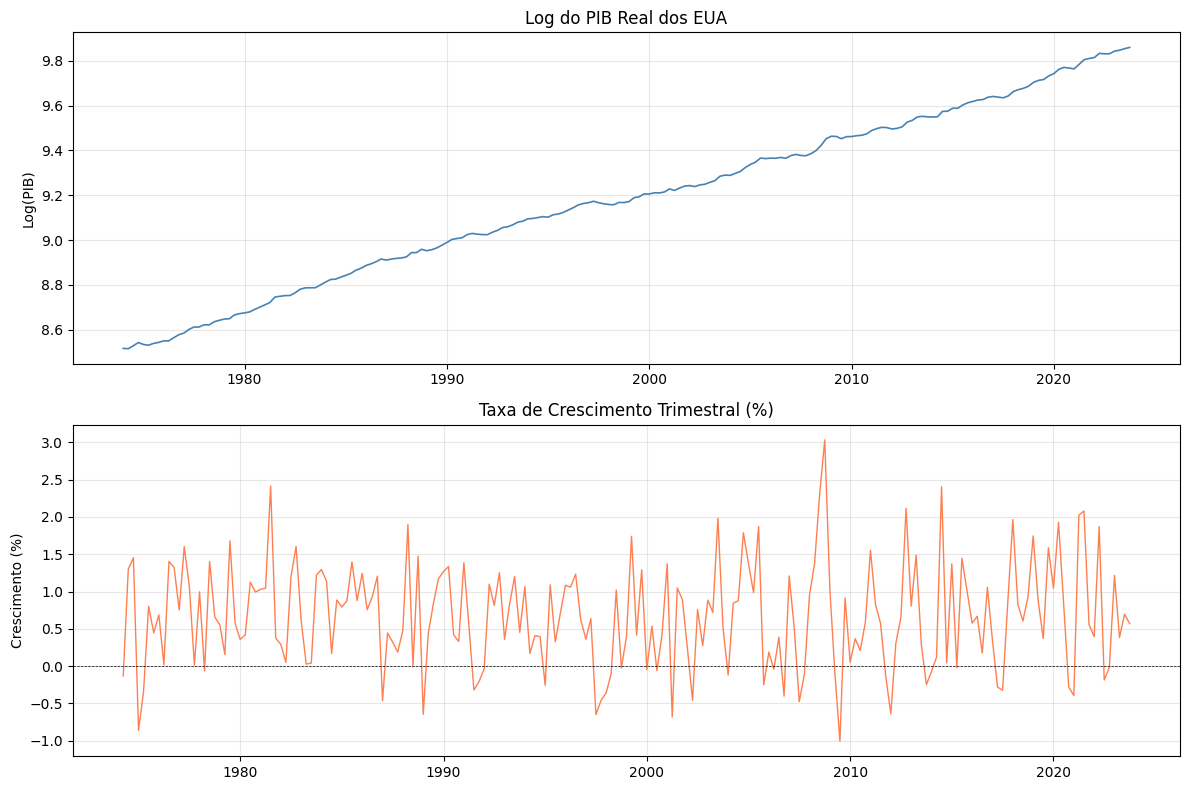

In [9]:
# Carregar dados do PIB dos EUA
gdp_us = pd.read_csv('../data/us_gdp_quarterly.csv', parse_dates=['date'], index_col='date')
print(f"Periodo: {gdp_us.index[0]} a {gdp_us.index[-1]}")
print(f"Observacoes: {len(gdp_us)}")
print(gdp_us.head())

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(gdp_us.index, gdp_us['log_gdp'], color='steelblue', linewidth=1.2)
axes[0].set_title('Log do PIB Real dos EUA')
axes[0].set_ylabel('Log(PIB)')
axes[0].grid(True, alpha=0.3)

gdp_growth = gdp_us['gdp_growth'].dropna()
axes[1].plot(gdp_growth.index, gdp_growth.values, color='coral', linewidth=1.0)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('Taxa de Crescimento Trimestral (%)')
axes[1].set_ylabel('Crescimento (%)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Testes ADF e PP no PIB EUA
log_gdp_us = gdp_us['log_gdp'].values
dlog_gdp_us = np.diff(log_gdp_us)

gdp_us_results = []

# Em nivel (com constante e com constante+tendencia)
for reg in ['c', 'ct']:
    gdp_us_results.append(run_adf_complete(log_gdp_us, f'Log PIB EUA (nivel)', reg))
    gdp_us_results.append(run_pp_complete(log_gdp_us, f'Log PIB EUA (nivel)', reg))

# Em primeira diferenca
gdp_us_results.append(run_adf_complete(dlog_gdp_us, 'Log PIB EUA (1a diferenca)', 'c'))
gdp_us_results.append(run_pp_complete(dlog_gdp_us, 'Log PIB EUA (1a diferenca)', 'c'))

print("\n>> Conclusao: Log PIB EUA e I(1) - estacionario em primeira diferenca")

=== ADF: Log PIB EUA (nivel) (regression='c', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : 0.144003
  p-value        : 0.990000
  Lags used      : 3

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -3.4650
      10% : -2.5746
       5% : -2.8763

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nobs: 196
    gamma: 0.000197
Decisao a 5%: Nao rejeita H0 (raiz unitaria)

=== PP: Log PIB EUA (nivel) (regression='c', lags='short') ===
  Phillips-Perron Test
  Test statistic : 0.004818
  p-value        : 0.990000
  Lags used      : 4

  H0: Unit root present (rho = 1)
  H1: Series is stationary (rho < 1)

  Critical Values:
       1% : -3.4645
      10% : -2.5744
       5% : -2.8761

  Decision (5%)  : Fail to reject H0

  Additional Info:
    Z_alpha: 0.001305
    bandwidth: 4
    regression: c
    nobs: 199
    rho_hat: 1.000009
    lambda_sq: 0.000050
    gamma_0: 0.000050
Dec

## 7. Exercicio 1 Resolvido: PIB do Brasil

O PIB do Brasil possui uma quebra estrutural por volta de 2003 (mudanca de regime economico). Vamos analisar como isso afeta os testes ADF e PP.

Periodo: 1994-01-01 00:00:00 a 2023-10-01 00:00:00
Observacoes: 120
            gdp_real   log_gdp  gdp_growth
date                                      
1994-01-01    800.00  6.684612         NaN
1994-04-01    793.24  6.676132     -0.8480
1994-07-01    803.63  6.689137      1.3005
1994-10-01    816.01  6.704424      1.5287
1995-01-01    800.32  6.685012     -1.9412


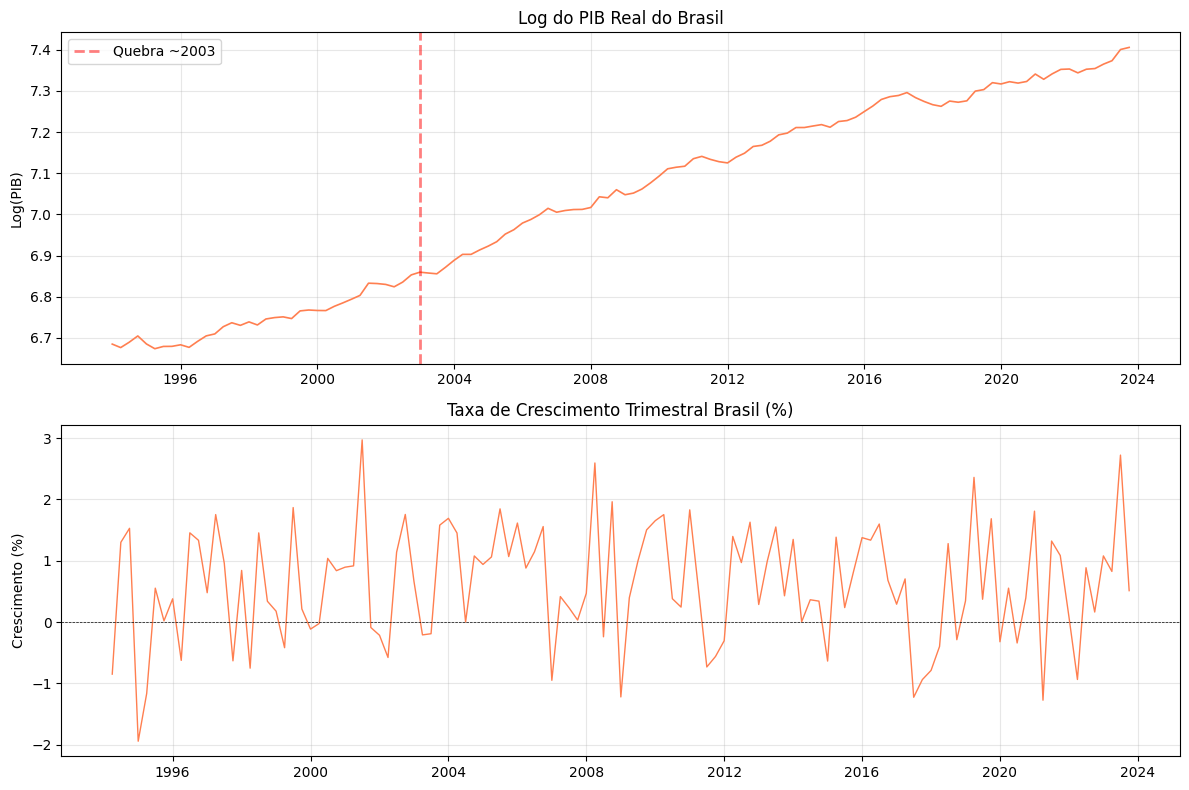

In [11]:
# Carregar PIB Brasil
gdp_br = pd.read_csv('../data/brazil_gdp.csv', parse_dates=['date'], index_col='date')
print(f"Periodo: {gdp_br.index[0]} a {gdp_br.index[-1]}")
print(f"Observacoes: {len(gdp_br)}")
print(gdp_br.head())

# Visualizar
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(gdp_br.index, gdp_br['log_gdp'], color='coral', linewidth=1.2)
axes[0].set_title('Log do PIB Real do Brasil')
axes[0].set_ylabel('Log(PIB)')
axes[0].grid(True, alpha=0.3)
# Marcar quebra ~2003
axes[0].axvline(x=pd.Timestamp('2003-01-01'), color='red', linestyle='--',
                linewidth=2, alpha=0.5, label='Quebra ~2003')
axes[0].legend()

growth_br = gdp_br['gdp_growth'].dropna()
axes[1].plot(growth_br.index, growth_br.values, color='coral', linewidth=1.0)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('Taxa de Crescimento Trimestral Brasil (%)')
axes[1].set_ylabel('Crescimento (%)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Exercicio 1.1: ADF e PP no log do PIB Brasil em nivel
log_gdp_br = gdp_br['log_gdp'].values
dlog_gdp_br = np.diff(log_gdp_br)

gdp_br_results = []

print("="*70)
print("  PIB BRASIL: Testes em Nivel")
print("="*70)

# ADF com constante
gdp_br_results.append(run_adf_complete(log_gdp_br, 'Log PIB Brasil (nivel)', 'c'))
# ADF com constante + tendencia
gdp_br_results.append(run_adf_complete(log_gdp_br, 'Log PIB Brasil (nivel)', 'ct'))
# PP com constante
gdp_br_results.append(run_pp_complete(log_gdp_br, 'Log PIB Brasil (nivel)', 'c'))
# PP com constante + tendencia
gdp_br_results.append(run_pp_complete(log_gdp_br, 'Log PIB Brasil (nivel)', 'ct'))

  PIB BRASIL: Testes em Nivel
=== ADF: Log PIB Brasil (nivel) (regression='c', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : 0.093814
  p-value        : 0.990000
  Lags used      : 0

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -3.4861
      10% : -2.5795
       5% : -2.8857

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nobs: 119
    gamma: 0.000355
Decisao a 5%: Nao rejeita H0 (raiz unitaria)

=== ADF: Log PIB Brasil (nivel) (regression='ct', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : -2.269663
  p-value        : 0.351268
  Lags used      : 0

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -4.0373
      10% : -3.1488
       5% : -3.4478

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: ct
    nobs: 119
    gamma: -0.074728
Decisao a 5%: Nao rejeita H0 (raiz u

In [13]:
# Exercicio 1.2: ADF e PP na primeira diferenca do PIB Brasil
print("="*70)
print("  PIB BRASIL: Testes na Primeira Diferenca")
print("="*70)

gdp_br_results.append(run_adf_complete(dlog_gdp_br, 'Log PIB Brasil (1a diferenca)', 'c'))
gdp_br_results.append(run_pp_complete(dlog_gdp_br, 'Log PIB Brasil (1a diferenca)', 'c'))

print("\n>> Conclusao: Log PIB Brasil e I(1) - estacionario em primeira diferenca")
print(">> NOTA: A quebra estrutural ~2003 pode causar vies de nao-rejeicao no ADF.")
print(">> Quando ha quebra estrutural, o ADF tende a nao rejeitar H0 mesmo quando")
print(">> a serie e estacionaria ao redor de uma tendencia com quebra.")
print(">> Para lidar com isso, deve-se usar o teste de Zivot-Andrews (notebook 02).")

  PIB BRASIL: Testes na Primeira Diferenca
=== ADF: Log PIB Brasil (1a diferenca) (regression='c', autolag='AIC') ===
  Augmented Dickey-Fuller Test
  Test statistic : -10.693728
  p-value        : 0.005000
  Lags used      : 0

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -3.4865
      10% : -2.5796
       5% : -2.8859

  Decision (5%)  : Reject H0

  Additional Info:
    regression: c
    nobs: 118
    gamma: -0.982637
Decisao a 5%: Rejeita H0 (estacionaria)

=== PP: Log PIB Brasil (1a diferenca) (regression='c', lags='short') ===
  Phillips-Perron Test
  Test statistic : -10.693593
  p-value        : 0.005000
  Lags used      : 4

  H0: Unit root present (rho = 1)
  H1: Series is stationary (rho < 1)

  Critical Values:
       1% : -3.4865
      10% : -2.5796
       5% : -2.8859

  Decision (5%)  : Reject H0

  Additional Info:
    Z_alpha: -115.138716
    bandwidth: 4
    regression: c
    nobs: 118
    rho_hat: 0.017363

## 8. Exercicio 2 Resolvido: Sensibilidade a Especificacao de Lags

Testamos o ADF com `maxlag` fixo de 1, 4, 8 e 12 na serie I(1) para avaliar a sensibilidade.

In [14]:
# Exercicio 2: Sensibilidade ao numero de lags
print("="*70)
print("  Exercicio 2: Sensibilidade ao Numero de Lags")
print("="*70)

lag_sensitivity = []
for k in [1, 4, 8, 12]:
    r = adf_test(y_unit_root.values, regression='c', maxlag=k, autolag=None)
    row = {
        'maxlag': k,
        'lags_used': int(r.lags_used),
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue),
        'reject_at_5pct': bool(r.reject_at_5pct),
    }
    lag_sensitivity.append(row)
    print(f"  maxlag={k:2d}: stat={r.statistic:.4f}, p={r.pvalue:.4f}, rejeita={r.reject_at_5pct}")

# Comparar com autolag
for method in ['AIC', 'BIC', 't-sig']:
    r = adf_test(y_unit_root.values, regression='c', autolag=method)
    row = {
        'maxlag': f'auto_{method}',
        'lags_used': int(r.lags_used),
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue),
        'reject_at_5pct': bool(r.reject_at_5pct),
    }
    lag_sensitivity.append(row)
    print(f"  auto({method:5s}): lags={r.lags_used}, stat={r.statistic:.4f}, p={r.pvalue:.4f}, rejeita={r.reject_at_5pct}")

# Tabela de sensibilidade
df_lag = pd.DataFrame(lag_sensitivity)
print("\n" + df_lag.to_string(index=False))

print("\n>> Recomendacao: Usar autolag='AIC' ou 'BIC' e a pratica padrao.")
print(">> AIC tende a selecionar mais lags (menor vies, maior variancia).")
print(">> BIC e mais parcimonioso. Poucos lags podem deixar autocorrelacao")
print(">> nos residuos; muitos lags reduzem o poder do teste.")

  Exercicio 2: Sensibilidade ao Numero de Lags
  maxlag= 1: stat=-1.4277, p=0.5009, rejeita=False
  maxlag= 4: stat=-1.1271, p=0.6060, rejeita=False
  maxlag= 8: stat=-0.8737, p=0.6946, rejeita=False
  maxlag=12: stat=-0.7530, p=0.7368, rejeita=False
  auto(AIC  ): lags=3, stat=-1.3021, p=0.5448, rejeita=False
  auto(BIC  ): lags=0, stat=-1.3271, p=0.5360, rejeita=False
  auto(t-sig): lags=3, stat=-1.3021, p=0.5448, rejeita=False

    maxlag  lags_used  statistic   pvalue  reject_at_5pct
         1          1  -1.427722 0.500889           False
         4          4  -1.127061 0.606013           False
         8          8  -0.873739 0.694586           False
        12         12  -0.752987 0.736812           False
  auto_AIC          3  -1.302095 0.544820           False
  auto_BIC          0  -1.327137 0.536045           False
auto_t-sig          3  -1.302095 0.544820           False

>> Recomendacao: Usar autolag='AIC' ou 'BIC' e a pratica padrao.
>> AIC tende a selecionar mais lags

## 9. Trend-Stationary vs Difference-Stationary

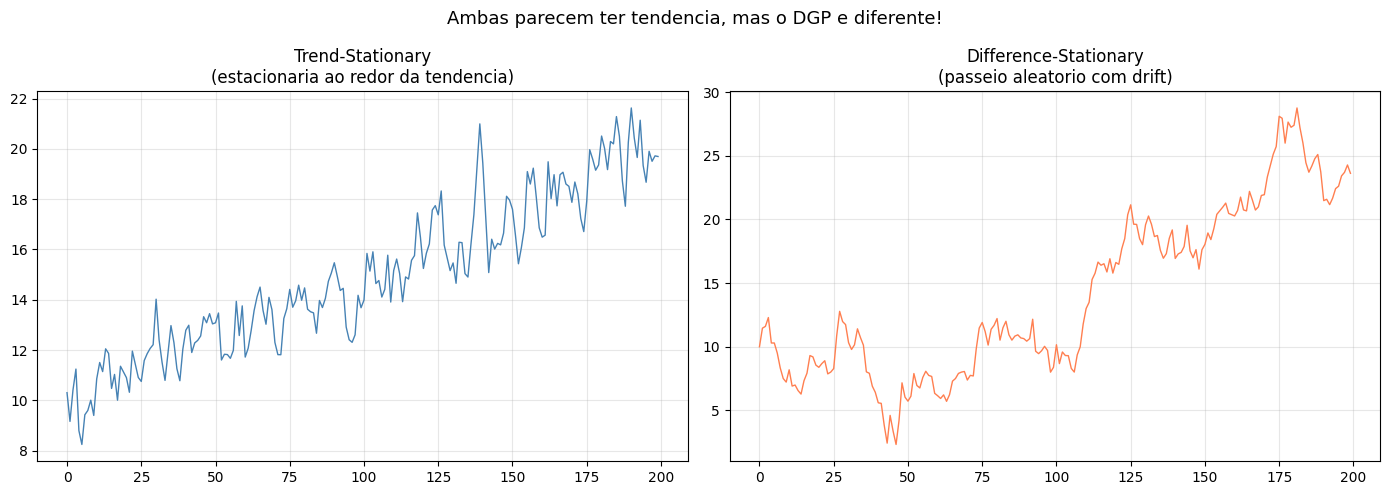

Trend-stationary (ADF, ct): stat=-7.7518, p=0.0050, rejeita=True
Difference-stationary (ADF, ct): stat=-2.7477, p=0.2125, rejeita=False
Trend-stationary (PP, ct): stat=-7.5466, p=0.0050, rejeita=True
Difference-stationary (PP, ct): stat=-2.7798, p=0.2033, rejeita=False


In [15]:
# Comparar trend-stationary vs difference-stationary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_trend['trend_stationary'], color='steelblue', linewidth=1.0)
axes[0].set_title('Trend-Stationary\n(estacionaria ao redor da tendencia)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_trend['difference_stationary'], color='coral', linewidth=1.0)
axes[1].set_title('Difference-Stationary\n(passeio aleatorio com drift)')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Ambas parecem ter tendencia, mas o DGP e diferente!', fontsize=13)
plt.tight_layout()
plt.show()

ts_results = []

# Trend-stationary com ADF(ct) - deve rejeitar H0
r_ts = adf_test(df_trend['trend_stationary'].values, regression='ct', autolag='AIC')
print(f"Trend-stationary (ADF, ct): stat={r_ts.statistic:.4f}, p={r_ts.pvalue:.4f}, rejeita={r_ts.reject_at_5pct}")
ts_results.append({
    'series': 'trend_stationary', 'test': 'ADF', 'regression': 'ct',
    'statistic': float(r_ts.statistic), 'pvalue': float(r_ts.pvalue),
    'reject_at_5pct': bool(r_ts.reject_at_5pct),
})

# Difference-stationary com ADF(ct) - NAO deve rejeitar
r_ds = adf_test(df_trend['difference_stationary'].values, regression='ct', autolag='AIC')
print(f"Difference-stationary (ADF, ct): stat={r_ds.statistic:.4f}, p={r_ds.pvalue:.4f}, rejeita={r_ds.reject_at_5pct}")
ts_results.append({
    'series': 'difference_stationary', 'test': 'ADF', 'regression': 'ct',
    'statistic': float(r_ds.statistic), 'pvalue': float(r_ds.pvalue),
    'reject_at_5pct': bool(r_ds.reject_at_5pct),
})

# PP nos mesmos dados
r_ts_pp = pp_test(df_trend['trend_stationary'].values, regression='ct')
r_ds_pp = pp_test(df_trend['difference_stationary'].values, regression='ct')
print(f"Trend-stationary (PP, ct): stat={r_ts_pp.statistic:.4f}, p={r_ts_pp.pvalue:.4f}, rejeita={r_ts_pp.reject_at_5pct}")
print(f"Difference-stationary (PP, ct): stat={r_ds_pp.statistic:.4f}, p={r_ds_pp.pvalue:.4f}, rejeita={r_ds_pp.reject_at_5pct}")

## 10. Tabela Resumo Consolidada com Decisao Final

In [16]:
# Tabela resumo consolidada
summary_table = []

all_series = {
    'I(0) sintetica': y_stationary.values,
    'I(1) sintetica - nivel': y_unit_root.values,
    'I(1) sintetica - 1a diff': dy,
    'I(1) com drift - nivel': y_rw_drift.values,
    'I(1) com drift - 1a diff': dy_drift,
    'I(2) sintetica - nivel': y_i2.values,
    'I(2) sintetica - 1a diff': dy_i2,
    'I(2) sintetica - 2a diff': ddy_i2,
    'Log PIB EUA - nivel': log_gdp_us,
    'Log PIB EUA - 1a diff': dlog_gdp_us,
    'Log PIB Brasil - nivel': log_gdp_br,
    'Log PIB Brasil - 1a diff': dlog_gdp_br,
    'Trend-stationary': df_trend['trend_stationary'].values,
    'Difference-stationary': df_trend['difference_stationary'].values,
}

for name, y in all_series.items():
    # Escolher especificacao adequada
    reg = 'ct' if 'nivel' in name or 'stationary' in name.lower() else 'c'
    if 'diff' in name:
        reg = 'c'
    
    r_adf = adf_test(y, regression=reg, autolag='AIC')
    r_pp = pp_test(y, regression=reg)
    
    summary_table.append({
        'Serie': name,
        'Espec.': reg,
        'ADF stat': f"{r_adf.statistic:.4f}",
        'ADF p': f"{r_adf.pvalue:.4f}",
        'ADF rejeita': 'Sim' if r_adf.reject_at_5pct else 'Nao',
        'PP stat': f"{r_pp.statistic:.4f}",
        'PP p': f"{r_pp.pvalue:.4f}",
        'PP rejeita': 'Sim' if r_pp.reject_at_5pct else 'Nao',
        'Decisao Final': (
            'Rejeita H0 (estacionaria)' 
            if r_adf.reject_at_5pct and r_pp.reject_at_5pct
            else 'Nao Rejeita H0 (raiz unitaria)'
            if not r_adf.reject_at_5pct and not r_pp.reject_at_5pct
            else 'Inconclusivo (testes divergem)'
        ),
    })

df_summary = pd.DataFrame(summary_table)
print("="*120)
print("  TABELA RESUMO FINAL: Testes ADF e Phillips-Perron")
print("="*120)
print(df_summary.to_string(index=False))

  TABELA RESUMO FINAL: Testes ADF e Phillips-Perron
                   Serie Espec. ADF stat  ADF p ADF rejeita  PP stat   PP p PP rejeita                  Decisao Final
          I(0) sintetica      c  -6.6649 0.0050         Sim  -6.1513 0.0050        Sim      Rejeita H0 (estacionaria)
  I(1) sintetica - nivel     ct  -1.8277 0.4762         Nao  -2.0678 0.4074        Nao Nao Rejeita H0 (raiz unitaria)
I(1) sintetica - 1a diff      c  -9.1342 0.0050         Sim -12.3789 0.0050        Sim      Rejeita H0 (estacionaria)
  I(1) com drift - nivel     ct  -1.8277 0.4762         Nao  -2.0678 0.4074        Nao Nao Rejeita H0 (raiz unitaria)
I(1) com drift - 1a diff      c  -9.1342 0.0050         Sim -12.3789 0.0050        Sim      Rejeita H0 (estacionaria)
  I(2) sintetica - nivel     ct  -1.8560 0.4681         Nao   0.4576 0.9900        Nao Nao Rejeita H0 (raiz unitaria)
I(2) sintetica - 1a diff      c  -1.1658 0.5925         Nao  -1.2976 0.5464        Nao Nao Rejeita H0 (raiz unitaria)
I(2)

## 11. Exportacao de Resultados em JSON

In [17]:
# Montar resultado final completo
output = {
    'metadata': {
        'notebook': '01_unit_root_adf_pp_solution',
        'tests': ['ADF', 'PP'],
        'seed': 42,
        'n_synthetic': 200,
    },
    'adf_results': adf_results,
    'pp_results': pp_results,
    'specification_comparison': spec_results,
    'lag_selection': lag_results,
    'lag_sensitivity': lag_sensitivity,
    'pp_bandwidth': pp_bandwidth_results,
    'gdp_us_results': gdp_us_results,
    'gdp_brazil_results': gdp_br_results,
    'trend_vs_difference': ts_results,
    'summary_table': summary_table,
}

# Salvar JSON
output_path = OUTPUT_DIR / 'adf_pp_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=str)

print(f"Resultados salvos em: {output_path}")
print(f"Total de testes ADF executados: {len(adf_results)}")
print(f"Total de testes PP executados: {len(pp_results)}")
print(f"Total de series na tabela resumo: {len(summary_table)}")

Resultados salvos em: ../outputs/adf_pp_results.json
Total de testes ADF executados: 8
Total de testes PP executados: 8
Total de series na tabela resumo: 14


## Conclusoes

1. **ADF e PP concordam** na maioria dos casos para series sinteticas com propriedades bem definidas
2. **Especificacao importa**: incluir tendencia desnecessariamente reduz o poder do teste
3. **Selecao de lags**: AIC e BIC produzem resultados similares; lag fixo pode distorcer resultados
4. **PIB EUA e Brasil**: ambos sao I(1) - estacionarios em primeira diferenca
5. **Quebra estrutural no PIB Brasil** pode causar vies de nao-rejeicao no ADF padrao
6. **Trend-stationary vs Difference-stationary**: ADF com `ct` distingue corretamente quando ha poder suficiente